In [1]:
import pandas as pd
import numpy as np

fear = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

print("Fear Data Shape:", fear.shape)
print("Trades Data Shape:", trades.shape)

Fear Data Shape: (2644, 4)
Trades Data Shape: (211224, 16)


In [2]:
fear.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [3]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [4]:
print("\nMissing values:\n", trades.isnull().sum())
print("\nDuplicate rows:", trades.duplicated().sum())


Missing values:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicate rows: 0


In [5]:
print("\nMissing values:\n", fear.isnull().sum())
print("\nDuplicate rows:", fear.duplicated().sum())


Missing values:
 timestamp         0
value             0
classification    0
date              0
dtype: int64

Duplicate rows: 0


In [9]:
fear.columns = fear.columns.str.strip().str.lower()
trades.columns = trades.columns.str.strip().str.lower()


In [17]:

fear['date'] = pd.to_datetime(fear['date']).dt.normalize()


trades['timestamp ist'] = pd.to_datetime(
    trades['timestamp ist'],
    format="%d-%m-%Y %H:%M"
)

trades['date'] = trades['timestamp ist'].dt.normalize()

In [18]:
merged = trades.merge(
    fear[['date','classification']],
    on='date',
    how='left'
)

In [19]:
print("Missing sentiment values:", merged['classification'].isna().sum())
print("Total rows:", len(merged))

Missing sentiment values: 6
Total rows: 211224


In [20]:
daily_pnl = merged.groupby(['account','date'])['closed pnl'].sum().reset_index()
daily_pnl.rename(columns={'closed pnl':'daily_pnl'}, inplace=True)

In [21]:
trade_count = merged.groupby(['account','date']).size().reset_index(name='trade_count')

In [23]:
merged['win'] = merged['closed pnl'] > 0

win_rate = merged.groupby(['account','date'])['win'].mean().reset_index()

In [24]:
avg_position = merged.groupby(['account','date'])['start position'].mean().reset_index()

In [25]:
daily_metrics = daily_pnl.merge(trade_count, on=['account','date'])
daily_metrics = daily_metrics.merge(win_rate, on=['account','date'])
daily_metrics = daily_metrics.merge(avg_position, on=['account','date'])

daily_metrics = daily_metrics.merge(
    merged[['date','classification']].drop_duplicates(),
    on='date'
)

In [26]:
daily_metrics.groupby('classification')['daily_pnl'].mean()
daily_metrics.groupby('classification')['win'].mean()
daily_metrics.groupby('classification')['trade_count'].mean()
daily_metrics.groupby('classification')['start position'].mean()

classification
Extreme Fear     -3717.120906
Extreme Greed     -791.382904
Fear              2226.701312
Greed              411.473707
Neutral          24490.470338
Name: start position, dtype: float64

In [28]:
daily_metrics.groupby('classification')['trade_count'].mean()


classification
Extreme Fear     133.750000
Extreme Greed     76.030418
Fear              98.153968
Greed             77.628086
Neutral          100.228723
Name: trade_count, dtype: float64

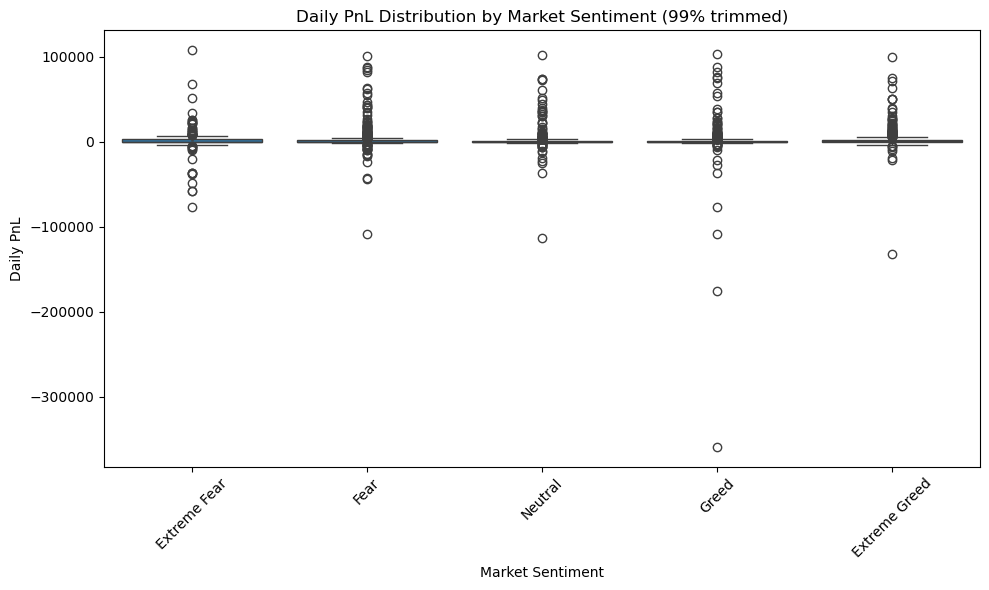

In [33]:
plt.figure(figsize=(10,6))

# Clip extreme PnL just for visualization
clip_limit = daily_metrics['daily_pnl'].quantile(0.99)
filtered = daily_metrics[daily_metrics['daily_pnl'] < clip_limit]

order = ['Extreme Fear','Fear','Neutral','Greed','Extreme Greed']

sns.boxplot(
    data=filtered,
    x='classification',
    y='daily_pnl',
    order=order
)

plt.title("Daily PnL Distribution by Market Sentiment (99% trimmed)")
plt.xlabel("Market Sentiment")
plt.ylabel("Daily PnL")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

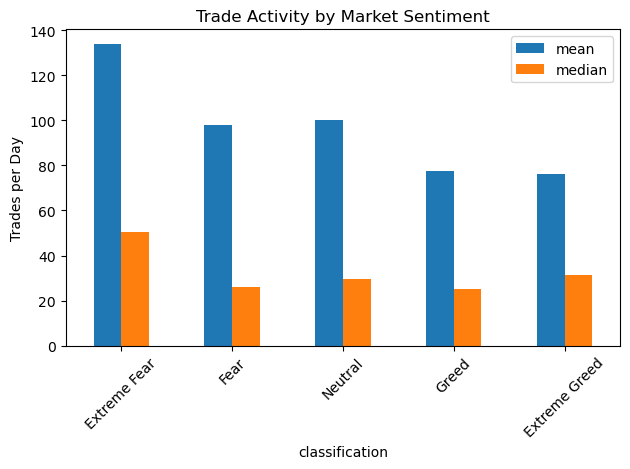

In [34]:
plt.figure(figsize=(10,6))

freq_stats = daily_metrics.groupby('classification')['trade_count'].agg(['mean','median'])
freq_stats = freq_stats.loc[order]

freq_stats.plot(kind='bar')

plt.title("Trade Activity by Market Sentiment")
plt.ylabel("Trades per Day")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

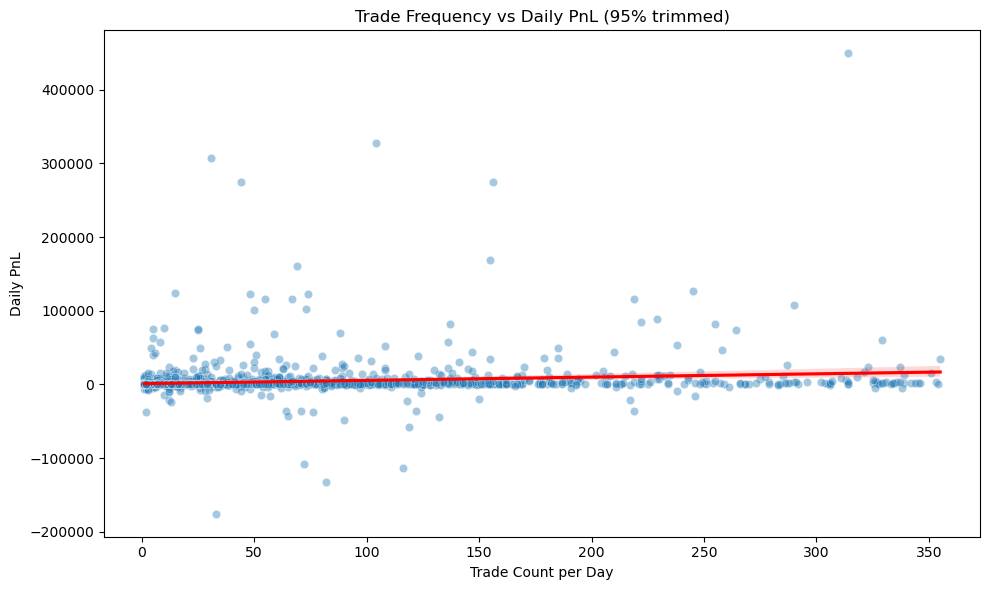

In [35]:
plt.figure(figsize=(10,6))

tc_limit = daily_metrics['trade_count'].quantile(0.95)
filtered = daily_metrics[daily_metrics['trade_count'] < tc_limit]

sns.scatterplot(
    data=filtered,
    x='trade_count',
    y='daily_pnl',
    alpha=0.4
)

sns.regplot(
    data=filtered,
    x='trade_count',
    y='daily_pnl',
    scatter=False,
    color='red'
)

plt.title("Trade Frequency vs Daily PnL (95% trimmed)")
plt.xlabel("Trade Count per Day")
plt.ylabel("Daily PnL")
plt.tight_layout()
plt.show()

In [36]:
daily_metrics = daily_metrics.sort_values(['account','date'])

daily_metrics['next_day_pnl'] = daily_metrics.groupby('account')['daily_pnl'].shift(-1)

daily_metrics['profit_next_day'] = (daily_metrics['next_day_pnl'] > 0).astype(int)

In [37]:
daily_metrics = daily_metrics.dropna(subset=['next_day_pnl'])

In [38]:
daily_metrics['classification'] = daily_metrics['classification'].astype('category').cat.codes

In [39]:
features = daily_metrics[
    ['classification','trade_count','win','start position']
]

target = daily_metrics['profit_next_day']

In [40]:
features = features.fillna(0)

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.6774891774891775
              precision    recall  f1-score   support

           0       0.62      0.30      0.41       169
           1       0.69      0.89      0.78       293

    accuracy                           0.68       462
   macro avg       0.66      0.60      0.59       462
weighted avg       0.66      0.68      0.64       462



In [43]:
daily_metrics.to_csv("daily_metrics.csv", index=False)